#SDG Indicator Text Classification
# Tasks: EDA, Preprocessing, Feature Engineering, Experiment Tracking

In [ ]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages

!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud plotly openpyxl -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import scipy.sparse as sp
import joblib

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter

# For feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All imports successful!")
print("Google Drive mounted at /content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports successful!
Google Drive mounted at /content/drive


In [ ]:
# Set project folder path
PROJECT_FOLDER = '/content/drive/MyDrive/SDG/'
import os
os.makedirs(PROJECT_FOLDER, exist_ok=True)
print("PROJECT_FOLDER set to:", PROJECT_FOLDER)

# Create visualization folder if it doesn't exist
os.makedirs(PROJECT_FOLDER + 'visualizations/', exist_ok=True)

PROJECT_FOLDER set to: /content/drive/MyDrive/SDG/


In [ ]:
# FIND DATASET FILES IN DRIVE

DRIVE_PATH = "/content/drive/MyDrive/SDG"

# Let's search for the files
import os

print("Searching for dataset files in your Drive...")
print("-" * 50)

# Search for Devex_train.csv
train_path = None
test_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive/SDG'):
    for file in files:
        if file == 'Devex_train.csv':
            train_path = os.path.join(root, file)
            print(f" Found training file: {train_path}")
        elif file == 'Devex_test_questions.csv':
            test_path = os.path.join(root, file)
            print(f" Found test file: {test_path}")

if train_path is None or test_path is None:
    print("\n Files not found automatically!")
    print("\nPlease enter the paths manually:")
    print("Example: /content/drive/MyDrive/SDG/Devex_train.csv")

    train_path = input("Enter full path to Devex_train.csv: ").strip()
    test_path = input("Enter full path to Devex_test_questions.csv: ").strip()

# Load the data
print("\n" + "=" * 60)
print("LOADING DATASETS")
print("=" * 60)

train_df = pd.read_csv(train_path, encoding='latin1')
test_df = pd.read_csv(test_path, encoding='latin1')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTraining columns: {train_df.columns.tolist()}")
print(f"Test columns: {test_df.columns.tolist()}")

# Display first few rows
print("\n" + "=" * 60)
print("FIRST 5 ROWS OF TRAINING DATA")
print("=" * 60)
train_df.head()

Searching for dataset files in your Drive...
--------------------------------------------------
 Found test file: /content/drive/MyDrive/SDG/Devex_test_questions.csv
 Found training file: /content/drive/MyDrive/SDG/Devex_train.csv

LOADING DATASETS
Training data shape: (2995, 15)
Test data shape: (998, 3)

Training columns: ['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']
Test columns: ['Unique ID', 'Type', 'Text']

FIRST 5 ROWS OF TRAINING DATA


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display detailed dataset information
print("=" * 60)
print("DATASET DETAILS")
print("=" * 60)

print("\n--- Training Data Info ---")
train_df.info()

print("\n--- Missing Values ---")
print(f"Missing values in training: {train_df.isnull().sum().sum()}")
print(f"Missing values in test: {test_df.isnull().sum().sum()}")

# Show column names to understand structure
print("\n--- Column Names ---")
print("Training columns:")
for i, col in enumerate(train_df.columns):
    print(f"  {i+1}. {col}")

print("\nTest columns:")
for i, col in enumerate(test_df.columns):
    print(f"  {i+1}. {col}")

DATASET DETAILS

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2995 entries, 0 to 2994
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique ID  2995 non-null   int64  
 1   Type       2995 non-null   object 
 2   Text       2995 non-null   object 
 3   Label 1    2995 non-null   object 
 4   Label 2    1635 non-null   object 
 5   Label 3    738 non-null    object 
 6   Label 4    312 non-null    object 
 7   Label 5    142 non-null    object 
 8   Label 6    59 non-null     object 
 9   Label 7    21 non-null     object 
 10  Label 8    10 non-null     object 
 11  Label 9    4 non-null      object 
 12  Label 10   2 non-null      object 
 13  Label 11   0 non-null      float64
 14  Label 12   0 non-null      float64
dtypes: float64(2), int64(1), object(12)
memory usage: 351.1+ KB

--- Missing Values ---
Missing values in training: 30022
Missing values in test: 0

--- Column Names --

## 2. Identify text column and SDG Indicator Columns

In [ ]:
# 2a. Find the text column
TEXT_COL = None
for candidate in ['Text', 'text', 'description', 'content', 'sentence', 'document', 'abstract']:
    if candidate in train_df.columns:
        TEXT_COL = candidate
        break
if TEXT_COL is None:
    for col in train_df.columns:
        if train_df[col].dtype == 'object' and not col.lower().startswith('label'):
            TEXT_COL = col
            break
assert TEXT_COL is not None, "Cannot find text column — check column names above."
print(f"Text column identified: '{TEXT_COL}'")

# 2b. Parse 'Label X' columns → binary indicator matrix
label_columns = [c for c in train_df.columns if c.lower().startswith('label')]
print(f"Found {len(label_columns)} label columns: {label_columns}")

unique_codes = set()
for col in label_columns:
    if train_df[col].dtype == 'object':
        for val in train_df[col].dropna().astype(str):
            code = val.split(' - ')[0].strip() if ' - ' in val else val.strip()
            if code:
                unique_codes.add(code)

SDG_INDICATORS = sorted(unique_codes)
print(f"\nExtracted {len(SDG_INDICATORS)} unique SDG indicator codes:")
for i, ind in enumerate(SDG_INDICATORS):
    print(f"  {i+1:2}. {ind}")

# Build binary columns
for ind in SDG_INDICATORS:
    train_df[ind] = 0

for col in label_columns:
    if train_df[col].dtype == 'object':
        for idx, val in train_df[col].dropna().items():
            code = val.split(' - ')[0].strip() if ' - ' in val else val.strip()
            if code in SDG_INDICATORS:
                train_df.loc[idx, code] = 1

print(f"\nBinary indicator columns created. Sample:")
display(train_df[SDG_INDICATORS].head(3))


Text column identified: 'Text'
Found 12 label columns: ['Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']

Extracted 27 unique SDG indicator codes:
   1. 3.1.1
   2. 3.1.2
   3. 3.2.1
   4. 3.2.2
   5. 3.3.1
   6. 3.3.2
   7. 3.3.3
   8. 3.3.4
   9. 3.3.5
  10. 3.4.1
  11. 3.4.2
  12. 3.5.1
  13. 3.5.2
  14. 3.6.1
  15. 3.7.1
  16. 3.7.2
  17. 3.8.1
  18. 3.8.2
  19. 3.9.1
  20. 3.9.2
  21. 3.9.3
  22. 3.a.1
  23. 3.b.1
  24. 3.b.2
  25. 3.b.3
  26. 3.c.1
  27. 3.d.1

Binary indicator columns created. Sample:


,3.1.1,3.1.2,3.2.1,3.2.2,3.3.1,3.3.2,3.3.3,3.3.4,3.3.5,3.4.1,...,3.8.2,3.9.1,3.9.2,3.9.3,3.a.1,3.b.1,3.b.2,3.b.3,3.c.1,3.d.1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# 3a. Basic statistics
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Total training samples : {len(train_df)}")
print(f"Total test samples     : {len(test_df)}")
print(f"SDG 3 indicators       : {len(SDG_INDICATORS)}")
print(f"Missing text values    : {train_df[TEXT_COL].isna().sum()}")

label_mat   = train_df[SDG_INDICATORS].values
label_counts = train_df[SDG_INDICATORS].sum().sort_values(ascending=False)
labels_per_doc = label_mat.sum(axis=1)

print(f"\n--- Label Statistics ---")
print(f"Avg labels per document : {labels_per_doc.mean():.2f}")
print(f"Max labels per document : {int(labels_per_doc.max())}")
print(f"Docs with 0 labels      : {(labels_per_doc == 0).sum()}")
print(f"Docs with 1 label       : {(labels_per_doc == 1).sum()}")
print(f"Docs with 2+ labels     : {(labels_per_doc >= 2).sum()}")

print("\n--- Top 10 Most Frequent Indicators ---")
for ind, cnt in label_counts.head(10).items():
    print(f"  {ind}: {cnt} ({cnt/len(train_df)*100:.1f}%)")

# Check for zero-support labels
zero_labels = label_counts[label_counts == 0].index.tolist()
if zero_labels:
    print(f"\n⚠ {len(zero_labels)} indicators with ZERO samples (will be excluded from modelling):")
    for z in zero_labels:
        print(f"  - {z}")
    SDG_INDICATORS = [i for i in SDG_INDICATORS if i not in zero_labels]
    print(f"Updated indicator list: {len(SDG_INDICATORS)} indicators")


DATASET STATISTICS
Total training samples : 2995
Total test samples     : 998
SDG 3 indicators       : 27
Missing text values    : 0

--- Label Statistics ---
Avg labels per document : 1.97
Max labels per document : 10
Docs with 0 labels      : 0
Docs with 1 label       : 1362
Docs with 2+ labels     : 1633

--- Top 10 Most Frequent Indicators ---
  3.b.2: 1040 (34.7%)
  3.8.1: 529 (17.7%)
  3.4.1: 483 (16.1%)
  3.b.3: 394 (13.2%)
  3.3.1: 371 (12.4%)
  3.2.1: 249 (8.3%)
  3.c.1: 232 (7.7%)
  3.1.1: 218 (7.3%)
  3.9.2: 217 (7.2%)
  3.d.1: 217 (7.2%)


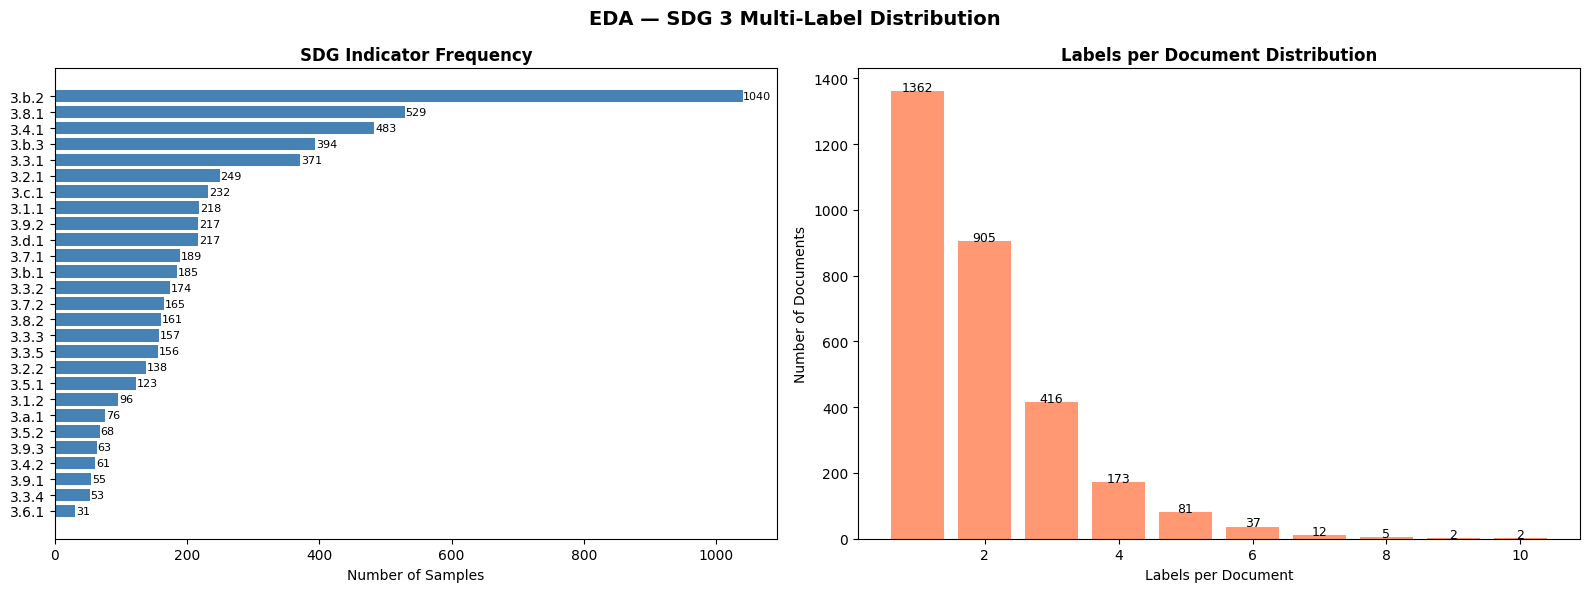

Saved: eda_label_distribution.png


In [ ]:
# 3b. Label distribution visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frequency bar chart
label_counts_filtered = train_df[SDG_INDICATORS].sum().sort_values(ascending=False)
axes[0].barh(label_counts_filtered.index, label_counts_filtered.values, color='steelblue')
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('SDG Indicator Frequency', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(label_counts_filtered.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=8)

# Distribution of labels per document
unique_counts, counts = np.unique(labels_per_doc, return_counts=True)
axes[1].bar(unique_counts, counts, color='coral', alpha=0.8)
axes[1].set_xlabel('Labels per Document')
axes[1].set_ylabel('Number of Documents')
axes[1].set_title('Labels per Document Distribution', fontweight='bold')
for x, y in zip(unique_counts, counts):
    axes[1].text(x, y + 0.5, str(y), ha='center', fontsize=9)

plt.suptitle('EDA — SDG 3 Multi-Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_label_distribution.png")


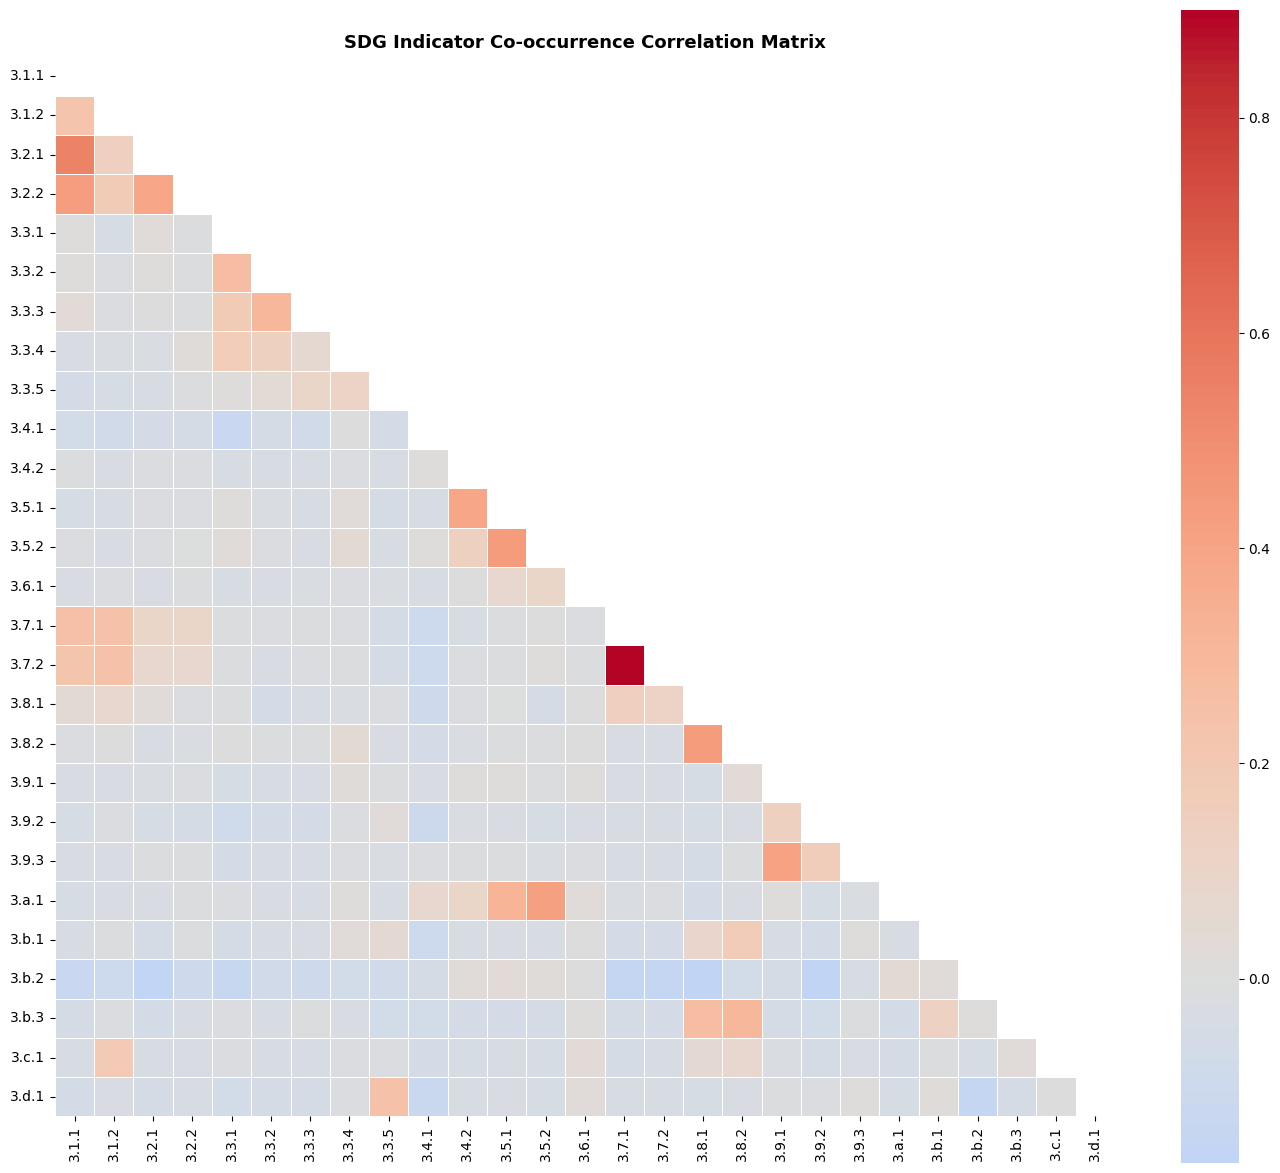

Saved: label_correlation.png

Top 5 most correlated indicator pairs:
  3.7.1 ↔ 3.7.2: r=0.900
  3.1.1 ↔ 3.2.1: r=0.544
  3.5.1 ↔ 3.5.2: r=0.443
  3.8.1 ↔ 3.8.2: r=0.437
  3.1.1 ↔ 3.2.2: r=0.429


In [ ]:
# 3c. Label co-occurrence heatmap
label_corr = train_df[SDG_INDICATORS].corr()
mask = np.triu(np.ones_like(label_corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(label_corr, mask=mask, cmap='coolwarm', center=0,
            annot=True if len(SDG_INDICATORS) <= 15 else False,
            fmt='.2f', square=True, linewidths=0.4, annot_kws={'size': 7})
plt.title('SDG Indicator Co-occurrence Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: label_correlation.png")

# Top correlated pairs
pairs = []
for i in range(len(SDG_INDICATORS)):
    for j in range(i+1, len(SDG_INDICATORS)):
        pairs.append((SDG_INDICATORS[i], SDG_INDICATORS[j], label_corr.iloc[i,j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("\nTop 5 most correlated indicator pairs:")
for a, b, r in pairs[:5]:
    print(f"  {a} ↔ {b}: r={r:.3f}")


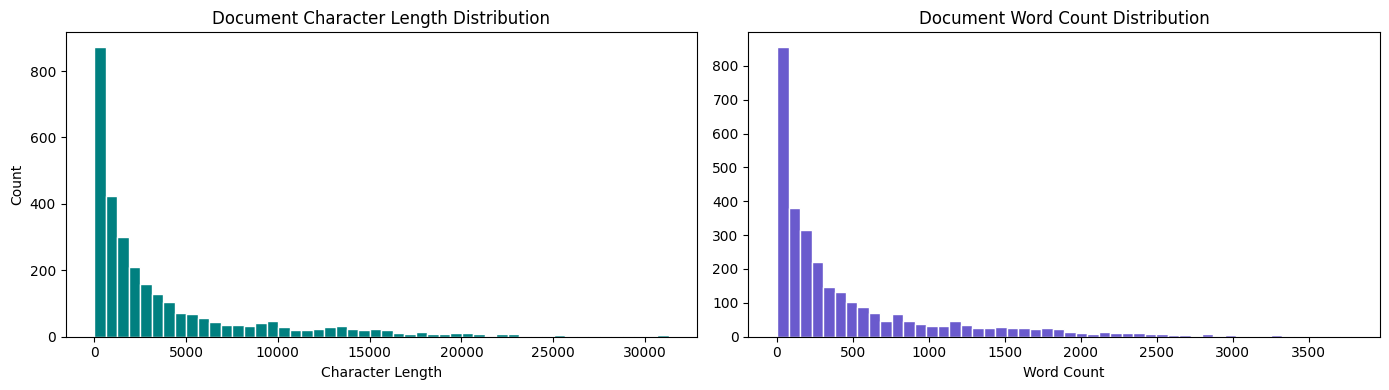

Word count — mean: 478, median: 211, max: 3781


In [ ]:
# 3d. Text length analysis
train_df[TEXT_COL] = train_df[TEXT_COL].fillna('').astype(str)
test_df[TEXT_COL if TEXT_COL in test_df.columns else test_df.columns[0]] =     test_df[TEXT_COL if TEXT_COL in test_df.columns else test_df.columns[0]].fillna('').astype(str)

train_df['char_length'] = train_df[TEXT_COL].apply(len)
train_df['word_count']  = train_df[TEXT_COL].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df['char_length'], bins=50, color='teal', edgecolor='white')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Document Character Length Distribution')
axes[1].hist(train_df['word_count'], bins=50, color='slateblue', edgecolor='white')
axes[1].set_xlabel('Word Count')
axes[1].set_title('Document Word Count Distribution')
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/eda_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Word count — mean: {train_df['word_count'].mean():.0f}, "
      f"median: {train_df['word_count'].median():.0f}, "
      f"max: {train_df['word_count'].max()}")


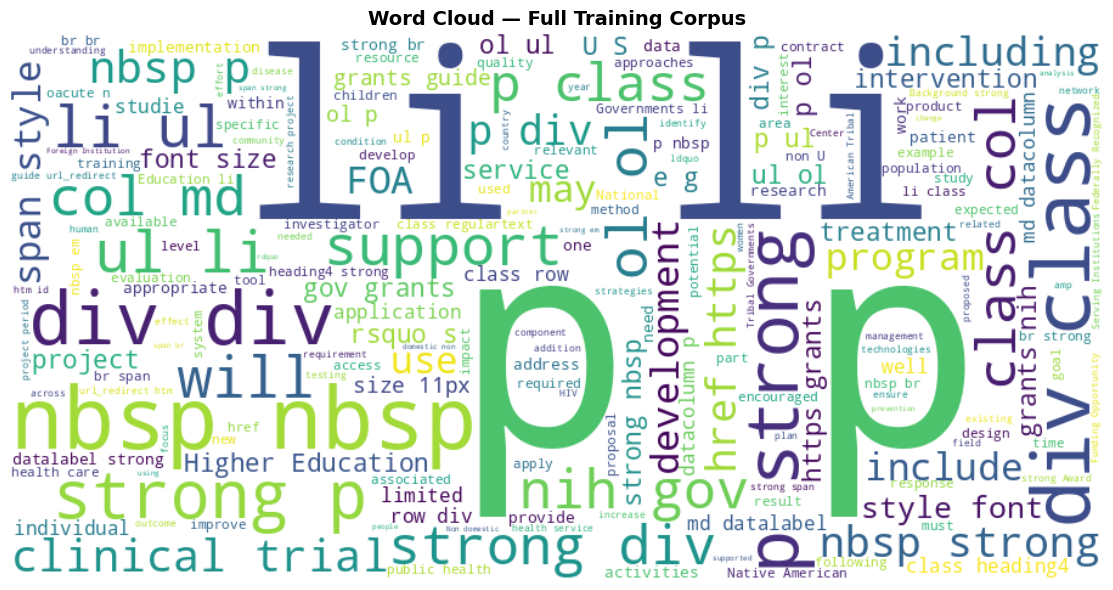

Saved: wordcloud_corpus.png


In [ ]:
# 3e. Word cloud of full corpus
all_text = ' '.join(train_df[TEXT_COL].values)
wc = WordCloud(width=900, height=450, background_color='white',
               colormap='viridis', max_words=200).generate(all_text)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Full Training Corpus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/wordcloud_corpus.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wordcloud_corpus.png")


In [ ]:
# 3f. Label co-occurrence — top combinations
combos = []
for i in range(len(train_df)):
    present = [SDG_INDICATORS[j] for j in range(len(SDG_INDICATORS))
               if train_df[SDG_INDICATORS].iloc[i, j] == 1]
    if present:
        combos.append(tuple(sorted(present)))

common_combos = Counter(combos).most_common(10)
print("Top 10 most frequent label combinations:")
for combo, cnt in common_combos:
    print(f"  {combo}: {cnt} docs ({cnt/len(train_df)*100:.1f}%)")


Top 10 most frequent label combinations:
  ('3.b.2',): 431 docs (14.4%)
  ('3.4.1',): 209 docs (7.0%)
  ('3.9.2',): 119 docs (4.0%)
  ('3.3.1',): 116 docs (3.9%)
  ('3.4.1', '3.b.2'): 94 docs (3.1%)
  ('3.b.2', '3.b.3'): 79 docs (2.6%)
  ('3.d.1',): 79 docs (2.6%)
  ('3.3.3',): 55 docs (1.8%)
  ('3.c.1',): 51 docs (1.7%)
  ('3.8.1',): 49 docs (1.6%)


## 4. Text Preprocessing

In [ ]:
# 4. Preprocessing pipeline
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text, strategy='lemma'):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)          # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)                  # non-alpha
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    if strategy == 'lemma':
        tokens = [lemmatizer.lemmatize(t) for t in tokens
                  if t not in stop_words and len(t) > 2]
    else:  # stem
        from nltk.stem import PorterStemmer
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(t) for t in tokens
                  if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Applying lemmatization preprocessing...")
train_df['text_clean_standard'] = train_df[TEXT_COL].apply(lambda x: preprocess_text(x, 'lemma'))

# Determine test text column
TEST_TEXT_COL = TEXT_COL if TEXT_COL in test_df.columns else test_df.select_dtypes('object').columns[0]
test_df['text_clean_standard']  = test_df[TEST_TEXT_COL].apply(lambda x: preprocess_text(x, 'lemma'))

print("Sample preprocessed text:")
for orig, clean in zip(train_df[TEXT_COL].head(2), train_df['text_clean_standard'].head(2)):
    print(f"  BEFORE: {orig[:120]}")
    print(f"  AFTER : {clean[:120]}")
    print()

# Save processed CSV (used by Notebooks 2 & 3)
train_df.to_csv(PROJECT_FOLDER + 'train_processed.csv', index=False)
print(f"Saved: train_processed.csv  ({len(train_df)} rows)")


Applying lemmatization preprocessing...
Sample preprocessed text:
  BEFORE: Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers     <p><strong>Funding Opportunity De
  AFTER : center biomedical research excellence cobre phase iii transitional center strong funding opportunity description strong 

  BEFORE: Research on Regenerative Medicine <h2><strong>Introduction</strong></h2>    <p>Supports translation of fundamental disco
  AFTER : research regenerative medicine strong introduction strong support translation fundamental discovery toward benefit human

Saved: train_processed.csv  (2995 rows)


## 5. Feature Engineering — TF-IDF & Multiple Vectorisers

In [ ]:
# 5. Build feature matrices
X_text     = train_df['text_clean_standard'].fillna('').values
X_text_test = test_df['text_clean_standard'].fillna('').values
y_full     = train_df[SDG_INDICATORS].values.astype(int)

print(f"Training documents : {len(X_text)}")
print(f"Test documents     : {len(X_text_test)}")
print(f"Label matrix shape : {y_full.shape}")

# ── Primary: Bigram TF-IDF (used in Notebooks 2-4)
vectorizer_bigram = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)
X_tfidf_bigram      = vectorizer_bigram.fit_transform(X_text)
X_tfidf_bigram_test = vectorizer_bigram.transform(X_text_test)

print(f"\nTF-IDF bigram matrix (train): {X_tfidf_bigram.shape}")
print(f"TF-IDF bigram matrix (test) : {X_tfidf_bigram_test.shape}")
print(f"Vocabulary size             : {len(vectorizer_bigram.vocabulary_)}")


Training documents : 2995
Test documents     : 998
Label matrix shape : (2995, 27)

TF-IDF bigram matrix (train): (2995, 10000)
TF-IDF bigram matrix (test) : (998, 10000)
Vocabulary size             : 10000


In [ ]:
# Compare vectoriser stats
# Unigram TF-IDF (for comparison / Exp 7)
vec_unigram = TfidfVectorizer(max_features=10000, ngram_range=(1,1), min_df=2, max_df=0.85, sublinear_tf=True)
X_unigram   = vec_unigram.fit_transform(X_text)

# CountVectorizer (for Exp 9)
vec_count = CountVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, max_df=0.85)
X_count   = vec_count.fit_transform(X_text)

print("Vectoriser comparison:")
print(f"  TF-IDF unigram: {X_unigram.shape}, density={X_unigram.nnz/(X_unigram.shape[0]*X_unigram.shape[1]):.5f}")
print(f"  TF-IDF bigram : {X_tfidf_bigram.shape}, density={X_tfidf_bigram.nnz/(X_tfidf_bigram.shape[0]*X_tfidf_bigram.shape[1]):.5f}")
print(f"  CountVec      : {X_count.shape}, density={X_count.nnz/(X_count.shape[0]*X_count.shape[1]):.5f}")


Vectoriser comparison:
  TF-IDF unigram: (2995, 10000), density=0.01459
  TF-IDF bigram : (2995, 10000), density=0.02006
  CountVec      : (2995, 10000), density=0.02006


## 6. Save All Artifacts to Drive

In [ ]:
# 6. Persist artifacts
# Feature matrices
sp.save_npz(PROJECT_FOLDER + 'features/X_tfidf_bigram.npz',  X_tfidf_bigram)
sp.save_npz(PROJECT_FOLDER + 'features/X_test_tfidf_bigram.npz', X_tfidf_bigram_test)
np.save(PROJECT_FOLDER + 'features/y_labels.npy',        y_full)
np.save(PROJECT_FOLDER + 'features/indicator_names.npy', np.array(SDG_INDICATORS))

# Vectorizer
joblib.dump(vectorizer_bigram, PROJECT_FOLDER + 'features/vectorizer_bigram.pkl')

# Test IDs (needed by Notebook 4 for final submission)
id_col = [c for c in test_df.columns if 'id' in c.lower()]
if id_col:
    test_df[id_col].to_csv(PROJECT_FOLDER + 'test_ids.csv', index=False)
else:
    pd.DataFrame({'row_id': range(len(test_df))}).to_csv(PROJECT_FOLDER + 'test_ids.csv', index=False)

print("All artifacts saved:")
print(f"  features/X_tfidf_bigram.npz         — {X_tfidf_bigram.shape}")
print(f"  features/X_test_tfidf_bigram.npz    — {X_tfidf_bigram_test.shape}")
print(f"  features/y_labels.npy               — {y_full.shape}")
print(f"  features/indicator_names.npy        — {len(SDG_INDICATORS)} indicators")
print(f"  features/vectorizer_bigram.pkl")
print(f"  train_processed.csv")
print(f"  test_ids.csv")
print("\n✓ Notebook 1 complete → proceed to Notebook 2 (Cynthia — Modeling)")


All artifacts saved:
  features/X_tfidf_bigram.npz         — (2995, 10000)
  features/X_test_tfidf_bigram.npz    — (998, 10000)
  features/y_labels.npy               — (2995, 27)
  features/indicator_names.npy        — 27 indicators
  features/vectorizer_bigram.pkl
  train_processed.csv
  test_ids.csv

✓ Notebook 1 complete → proceed to Notebook 2 (Cynthia — Modeling)
